# Unstructured Data Analytics HW3

Your name: Qirui Chen

Your Andrew ID: qiruic

Human or AI collaborators (if none, say "none"; do not leave this blank): none

**Reminder:** You should not be sharing code with other humans. If you ask an AI collaborator to code for you, please state when you are taking code from the AI collaborator (you can just briefly state it; we do not need details on prompt(s) you used nor do we need to see a transcript of any conversation you had with the AI collaborator) and make a genuine effort at understanding whether the code actually works correctly. Please keep in mind that for quizzes, we will check whether you understand various coding concepts (without help from anyone else, whether human or AI). We recommend that you do not purely rely on an AI collaborator to do all the coding for you, where you don't actually learn to do any of it yourself (i.e., we would recommend against just [*vibe coding*](https://en.wikipedia.org/wiki/Vibe_coding) your way through the homework if you intend on understanding the coding aspects well enough to do well on the quizzes).

# Part 1: Email spam classification [30 points]

   - Get the data from: http://www.andrew.cmu.edu/user/georgech/preprocessed-enron-email-dataset.zip
   - Unzip this into the same folder as this notebook, rename it to `email-data`
   - The folder contains 3 subfolders:
      - `ham` contains ham emails.
      - `spam` contains spam emails.
      - `testing` is a folder containing test emails for your classifier. The ham/spam label is in the filename.
      
**Important**: For this problem, do *not* use neural nets/deep nets.

**(a) Print the number of ham and spam emails [1 point]**

In addition to providing the code, respond to the following questions:

   - Is this dataset imbalanced? Will this be problematic in training the model?
   - If so, how would you address it? (You do *not* have to implement what you suggest here for later parts of the problem.)

In [8]:
from pathlib import Path

email_dir_candidates = [Path("email-data"), Path("preprocessed-enron-email-dataset")]
email_dir = next((path for path in email_dir_candidates if path.exists()), None)
if email_dir is None:
    raise FileNotFoundError(
        "Could not find the email dataset folder. Expected either 'email-data' or "
        "'preprocessed-enron-email-dataset'."
    )

ham_files = sorted((email_dir / "ham").glob("*.txt"))
spam_files = sorted((email_dir / "spam").glob("*.txt"))

print(f"Using email dataset folder: {email_dir}")
print(f"Number of ham emails: {len(ham_files)}")
print(f"Number of spam emails: {len(spam_files)}")
print(f"Spam proportion: {len(spam_files) / (len(ham_files) + len(spam_files)):.3f}")

Using email dataset folder: preprocessed-enron-email-dataset
Number of ham emails: 1500
Number of spam emails: 3671
Spam proportion: 0.710


**Your answers to the above questions:**

The dataset is imbalanced: there are 1500 ham emails and 3671 spam emails, so spam makes up about 71% of the data. This can bias a classifier toward predicting the majority class more often, so using a stratified train/validation split and an evaluation metric such as weighted F1 is important.

**(b) Construct the documents [4 points]**
 
   - Provided below is a function that returns a document present in a file given a filename.
   - The function performs some preprocessing to (1) remove punctuation, (2),(3) remove whitespace and (4) lowercase all words.
   - Use this function to construct a list of documents.
   - Also construct a list of document labels containing `1` for spam and `0` for ham.

In [9]:
import re
import string
import codecs

def make_word_list(path):
    
    with codecs.open(path, "r", encoding='utf-8', errors='ignore') as f:
        corpus_text = f.read()

    for c in string.punctuation:
        corpus_text = corpus_text.replace(c, "")  # -- (1)
    
    text = re.sub(r'\S*\d\S*','',corpus_text) # -- (2)
    text = re.sub(r'[^\w\s]','',text)         # -- (3)
    
    text = text.lower().split()           # -- (4)         
    
    li = []
    for token in text:
        li.append(token)

    return " ".join(li)

In [10]:
import numpy as np

file_paths = ham_files + spam_files
documents = [make_word_list(str(path)) for path in file_paths]
labels = np.array([0] * len(ham_files) + [1] * len(spam_files))

print(f"Constructed {len(documents)} documents.")
print("First document preview:", documents[0][:200])

Constructed 5171 documents.
First document preview: subject leadership development pilot sally what timing ask and you shall receive as per our discussion listed below is an update on the leadership pilot your vendor selection team will receive an upda


**(c) Construct the document matrix `X` as a matrix of word frequencies [5 points]**

   - Use the `CountVectorizer` from scikit-learn.
   - Set `min_df=50`; this drops words that don't occur in at least 50 documents.
   - Set `stop_words="english"` and `max_df=0.8` to filter out stop-words.
   - Print the size of the vocabulary (number of unique words)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(min_df=50, stop_words="english", max_df=0.8)
X = vectorizer.fit_transform(documents)

print("Document matrix shape:", X.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Document matrix shape: (5171, 1680)
Vocabulary size: 1680


**(d) k-NN: Hyperparameter selection [5 points]**

Now that you have your documents and labels as training data, you can use a validation set to help select hyperparameters for a k-NN classifier.

Please use the **weighted F1-score** as the evaluation metric (i.e., for the `f1_score` function imported from `sklearn.metrics`, be sure to use the parameter `average='weighted'`).

Provided is some seed code for hyperparameter tuning that you may modify and reuse.

In [12]:
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

hyperparameter_settings = [
    {"n_neighbors": k, "weights": weights, "metric": metric, "algorithm": "brute"}
    for k in [1, 3, 5, 7, 9, 11, 15]
    for weights in ["uniform", "distance"]
    for metric in ["cosine", "euclidean"]
]

X_train, X_val, y_train, y_val = train_test_split(
    X, labels, test_size=0.2, random_state=0, stratify=labels
)

best_score = -np.inf
best_hyperparam_setting = None
best_model = None
validation_rows = []

for hyperparam_setting in hyperparameter_settings:
    model = KNeighborsClassifier(**hyperparam_setting)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    score = f1_score(y_val, val_pred, average="weighted")
    validation_rows.append({**hyperparam_setting, "weighted_f1": score})

    if score > best_score:
        best_score = score
        best_hyperparam_setting = hyperparam_setting

best_model = KNeighborsClassifier(**best_hyperparam_setting)
best_model.fit(X, labels)

validation_results_df = pd.DataFrame(validation_rows).sort_values(
    by="weighted_f1", ascending=False
)
print(validation_results_df.head(10).to_string(index=False))
print()
print("Best hyperparameter setting:", best_hyperparam_setting)
print(f"Best validation weighted F1: {best_score:.4f}")

 n_neighbors  weights metric algorithm  weighted_f1
           5 distance cosine     brute     0.985426
           3 distance cosine     brute     0.984462
           5  uniform cosine     brute     0.983483
           7 distance cosine     brute     0.983465
          11 distance cosine     brute     0.983465
           9 distance cosine     brute     0.983465
           3  uniform cosine     brute     0.982520
          11  uniform cosine     brute     0.982483
           9  uniform cosine     brute     0.982483
           7  uniform cosine     brute     0.982483

Best hyperparameter setting: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'cosine', 'algorithm': 'brute'}
Best validation weighted F1: 0.9854


**(e) Classifier testing: Precision-Recall and ROC curves [15 points]**

Use test emails in the `testing` folder to **test** your best k-NN classifier (the one stored in `best_model` after running your code for part (d)) and construct the plots below.

Things to plot:

   - Construct an ROC curve for a k-NN classifier. (We vary the threshold probability of declaring an email to be spam to obtain these plots.) In the legend of this plot, display the AUC for the k-NN classifier.
   - Construct one plot containing a precision-recall curve for the k-NN classifier. In the legend of this plot, display the average precision for each classifier using the sklearn function [`average_precision_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html#sklearn.metrics.average_precision_score); average precision is essentially an approximation of the area under the precision-recall curve that avoids being overly optimistic.

Note that these plots are on the test data: you will have to read in this data, construct a document matrix and labels. Some words in the test data may not have been present in the training data: there are multiple ways to address this, briefly describe your approach.

Things to answer:

   - Of the ROC and Precision-Recall curves, which one would you use for this task and why?

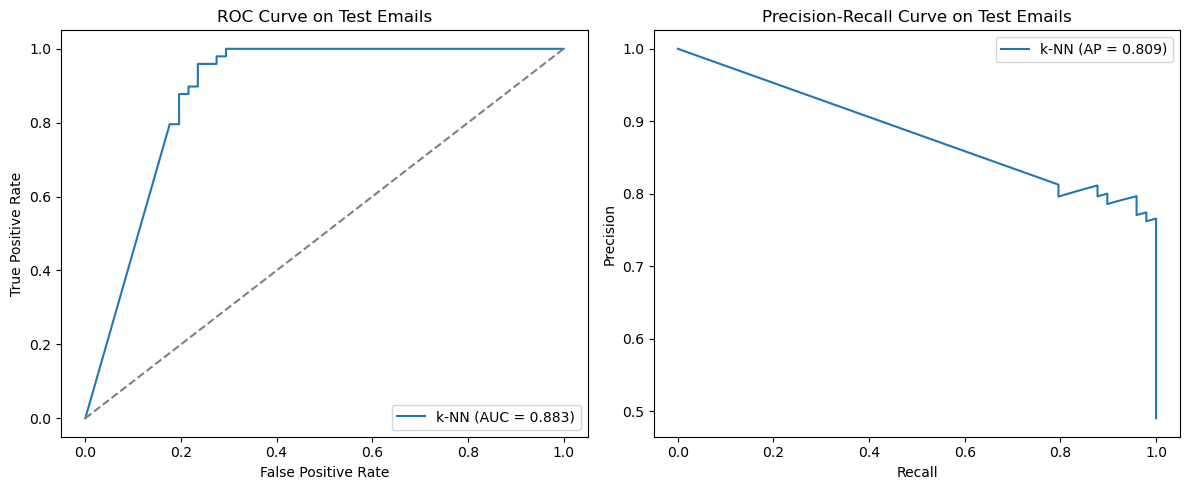

Test ROC AUC: 0.8834
Test average precision: 0.8088


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

test_files = sorted((email_dir / "testing").glob("*.txt"))
test_documents = [make_word_list(str(path)) for path in test_files]
y_test_email = np.array([1 if ".spam." in path.name else 0 for path in test_files])

# We reuse the training vocabulary; words that were unseen during training are ignored by transform().
X_test_email = vectorizer.transform(test_documents)
spam_prob = best_model.predict_proba(X_test_email)[:, 1]

roc_fpr, roc_tpr, _ = roc_curve(y_test_email, spam_prob)
pr_precision, pr_recall, _ = precision_recall_curve(y_test_email, spam_prob)
roc_auc = roc_auc_score(y_test_email, spam_prob)
avg_precision = average_precision_score(y_test_email, spam_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(roc_fpr, roc_tpr, label=f"k-NN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Emails")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pr_recall, pr_precision, label=f"k-NN (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve on Test Emails")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Test ROC AUC: {roc_auc:.4f}")
print(f"Test average precision: {avg_precision:.4f}")

**Your answer to the final non-coding question:**

I used the training-set vocabulary learned by `CountVectorizer` and then called `vectorizer.transform(...)` on the test documents. Any out-of-vocabulary words in the test set are simply dropped, while words seen during training are mapped to the same columns as before.

For spam detection, I would prefer the precision-recall curve. The training set is imbalanced, and in imbalanced settings ROC curves can look overly optimistic because they include true negatives so heavily. A precision-recall curve focuses more directly on how well the model identifies spam while balancing missed spam against false alarms.

# Part 2: Representation Learning [40 points]

Before getting started, please put the attached file `pretrained_convnet.pt` in the same directory as this notebook.

Recall from lecture the "crumpled paper analogy": in a neural net, as you progress through the layers from input to output, the layers should be "unfolding the original space" to disentangle the classes. When you get to the layer before the classifier, you should've changed the data representation into something that makes classification easy. **We will refer to the layer before the classifier in the neural net as the bottleneck layer.**

In this problem, you will be using an output of a bottleneck layer from pre-trained CNN as input features for a few simple classifiers. The CNN provided was trained with the Fashion MNIST dataset which consists of 10 classes of 28x28 grayscale images; this dataset is very similar to MNIST in that there are 10 classes with images that are the same size as MNIST and in fact even the training and test set sizes are the same (60,000 and 10,000 respectively). However, the classes are not the digits 0 through 9. Instead the classes are:

| Class | Description |
| ----- | :---------: |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

Let's start with some imports.

In [14]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from copy import deepcopy

try:
    from torchinfo import summary
except ModuleNotFoundError:
    def summary(model, input_data=None):
        total_params = sum(param.numel() for param in model.parameters())
        trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
        return (
            f"{model}\n"
            f"Total params: {total_params}\n"
            f"Trainable params: {trainable_params}"
        )

def _resolve_device(device=None):
    if device is None:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)

def UDA_pytorch_model_transform(model, x, batch_size=256, device=None):
    device = _resolve_device(device)
    model = model.to(device)
    model.eval()

    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            batch = x[start : start + batch_size].to(device)
            outputs.append(model(batch).cpu())
    return torch.cat(outputs, dim=0)

def UDA_pytorch_classifier_predict(model, x, batch_size=256, device=None):
    logits = UDA_pytorch_model_transform(model, x, batch_size=batch_size, device=device)
    return logits.argmax(dim=1)

def UDA_compute_accuracy(y_true, y_pred):
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

def UDA_pytorch_classifier_fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    device=None,
    clip_grad_norm=1.0,
):
    device = _resolve_device(device)
    model = model.to(device)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_acc = -np.inf

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            optimizer.step()

            train_loss += loss.item() * len(yb)
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            train_total += len(yb)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * len(yb)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += len(yb)

        epoch_train_loss = train_loss / train_total
        epoch_val_loss = val_loss / val_total
        epoch_train_acc = train_correct / train_total
        epoch_val_acc = val_correct / val_total

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={epoch_train_loss:.4f}, train_acc={epoch_train_acc:.4f}, "
            f"val_loss={epoch_val_loss:.4f}, val_acc={epoch_val_acc:.4f}"
        )

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_state = deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

def UDA_plot_train_val_accuracy_vs_epoch(train_acc_history, val_acc_history):
    epochs = np.arange(1, len(train_acc_history) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_acc_history, marker="o", label="Train accuracy")
    plt.plot(epochs, val_acc_history, marker="s", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xticks(epochs)
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

**Loading in the data.** We first load the Fashion MNIST dataset and plot some example images.

/var/folders/qx/0qfp5_9j0ps66xcmg76t7pb40000gn/T/ipykernel_22884/3756618938.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226120/work/torch/csrc/utils/tensor_new.cpp:278.)
  train_images = torch.tensor([image.numpy() for image, label in train_dataset])


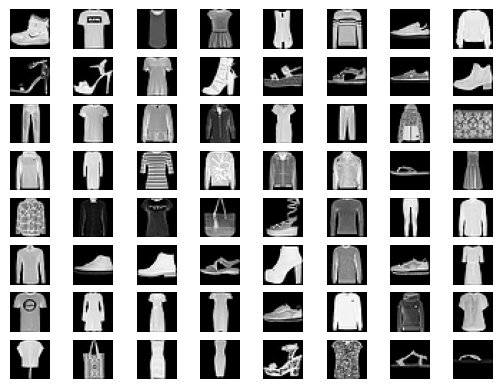

In [15]:
# do not modify this cell
train_dataset = torchvision.datasets.FashionMNIST(root='data/',
                                                  train=True,
                                                  transform=transforms.ToTensor(),
                                                  download=True)

train_images = torch.tensor([image.numpy() for image, label in train_dataset])
train_labels = torch.tensor([label for image, label in train_dataset])

test_dataset = torchvision.datasets.FashionMNIST(root='data/',
                                                 train=False,
                                                 transform=transforms.ToTensor(),
                                                 download=True)

test_images = torch.tensor([image.numpy() for image, label in test_dataset])
test_labels = torch.tensor([label for image, label in test_dataset])

# show some of the first training images
square_grid_num_rows = 8
num_images_to_show = square_grid_num_rows ** 2
for idx in range(num_images_to_show):
    plt.subplot(square_grid_num_rows, square_grid_num_rows, idx + 1)
    plt.imshow(train_images[idx][0], cmap='gray')
    plt.axis('off')

**(a) [5 points]** Select train and test data that belong to classes 2 (corresponding to pullovers) or 6 (corresponding to fancier shirts than t-shirts; note: class 0 corresponds to t-shirts), i.e., subsample all the data that has label 2 or 6. Save the variables as `x_train`, `x_test`, `y_train`, `y_test`. From now on, we are only dealing with the images that are in classes 2 (pullovers) or 6 (shirts). Moreover, in `y_train` and `y_test`, please renumber the two classes so that pullovers now instead corresponds to 0 and shirts corresponds to 1 (we will consider shirts to be the "positive" class and pullovers to be the "negative" class).

In [16]:
train_mask = (train_labels == 2) | (train_labels == 6)
test_mask = (test_labels == 2) | (test_labels == 6)

x_train = train_images[train_mask]
y_train = (train_labels[train_mask] == 6).long()

x_test = test_images[test_mask]
y_test = (test_labels[test_mask] == 6).long()

In [17]:
# do not modify this cell
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

torch.Size([12000, 1, 28, 28]) torch.Size([12000])
torch.Size([2000, 1, 28, 28]) torch.Size([2000])


We will make some t-SNE visualizations shortly and using all the training data will be too slow. We reduce the size of the training dataset by randomly subsampling 1000 samples from `x_train`/`y_train` pairs and saving the subsampled versions as `x_train_small`/`y_train_small` (the i-th image in `x_train_small` should have its label given by the i-th entry in `y_train_small`). We have provided the indices of which 1000 samples to use (from within `x_train`/`y_train`).

In [18]:
# do not modify this cell
np.random.seed(0)
random_sample = np.random.permutation(len(x_train))[:1000]

In [19]:
x_train_small = x_train[random_sample]
y_train_small = y_train[random_sample]

**(b) [10 points]** We are ready to load the pre-trained convnet. The bottleneck layer is right before the final linear layer and corresponds to the output of a ReLU that has 84 values. **We refer to the output of this ReLU as the bottleneck feature vector representation of whatever the input is.**

Note that the convnet was pre-trained using the entire training dataset which consists of 60,000 samples and all 10 labels.

In [20]:
# load the pre-trained CNN
convnet = nn.Sequential(nn.Conv2d(1, 6, 3),
                        nn.ReLU(),
                        nn.MaxPool2d(2),
                        nn.Conv2d(6, 16, 3),
                        nn.ReLU(),
                        nn.MaxPool2d(2),
                        nn.Flatten(),
                        nn.Linear(in_features=16 * 5 * 5, out_features=120),
                        nn.ReLU(),
                        nn.Linear(in_features=120, out_features=84),
                        nn.ReLU(),
                        nn.Linear(in_features=84, out_features=10))
convnet.load_state_dict(torch.load("pretrained_convnet.pt", map_location=torch.device("cpu")))
convnet.eval()
print("[Summary of pre-trained convnet]")
print(summary(convnet, input_data=torch.zeros((1, 1, 28, 28))))
print()

# select the pretrained CNN upto the bottleneck layer
intermediate_layer_model = convnet[:-1]
print("[Summary of the pre-trained convnet up to the bottleneck layer]")
print(summary(intermediate_layer_model, input_data=torch.zeros((1, 1, 28, 28))))

[Summary of pre-trained convnet]
Sequential(
  (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): ReLU()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)
Total params: 60074
Trainable params: 60074

[Summary of the pre-trained convnet up to the bottleneck layer]
Sequential(
  (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

We first extract bottleneck feature vectors of the subsampled 1000 training data from the intermediate model.

In [21]:
# do not modify this cell
x_train_small_bottleneck_representation = UDA_pytorch_model_transform(intermediate_layer_model, x_train_small)

Next, visualize two different types of features with t-SNE.

1. Make a t-SNE plot using the **784 (=28$\times$28) dimensional raw features** from the subsampled training data (i.e., using `x_train_small`). Set `n_components=2, verbose=1, perplexity=25, random_state=0` for `TSNE` from scikit-learn. Plot the two classes in different colors.

2. Repeat the previous step (using the exact same arguments for `TSNE`) except now using the **84 dimensional bottleneck features** (i.e., using `x_train_small_bottleneck_representation`.

You may need to convert between PyTorch tensors and NumPy arrays.

[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.140s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 1.929497
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.887581
[t-SNE] KL divergence after 1000 iterations: 1.063658
[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.017s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 2.053075
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.685089
[t-SNE] KL divergence after 1000 iterations: 0.991901


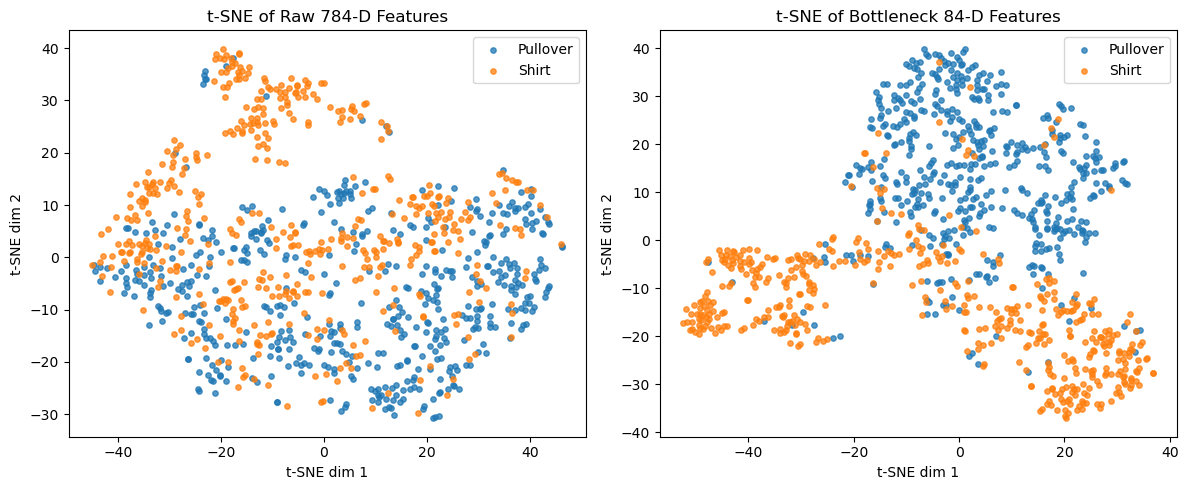

In [22]:
from sklearn.manifold import TSNE

label_names = {0: "Pullover", 1: "Shirt"}
colors = {0: "tab:blue", 1: "tab:orange"}

raw_features_small = x_train_small.view(len(x_train_small), -1).numpy()
raw_tsne = TSNE(
    n_components=2, verbose=1, perplexity=25, random_state=0
).fit_transform(raw_features_small)

bottleneck_features_small = x_train_small_bottleneck_representation.numpy()
bottleneck_tsne = TSNE(
    n_components=2, verbose=1, perplexity=25, random_state=0
).fit_transform(bottleneck_features_small)

y_train_small_np = y_train_small.numpy()

plt.figure(figsize=(12, 5))
for subplot_idx, (embedding, title) in enumerate(
    [
        (raw_tsne, "t-SNE of Raw 784-D Features"),
        (bottleneck_tsne, "t-SNE of Bottleneck 84-D Features"),
    ],
    start=1,
):
    plt.subplot(1, 2, subplot_idx)
    for label in [0, 1]:
        mask = y_train_small_np == label
        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=15,
            alpha=0.75,
            c=colors[label],
            label=label_names[label],
        )
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()

plt.tight_layout()
plt.show()

**(c) [15 points]** We now evaluate on test data and compare several classifiers. Train a **5-NN** classifier (i.e., 5-nearest-neighbor classifier) with **784 (=28$\times$28) raw features** and, separately, the **84 bottleneck features** from **all training data**, respectively. That means you should train 2 models in total:

1. 5-NN classifier trained on all raw training features
2. 5-NN classifier trained on all training bottleneck features

Test each model on the **test dataset** and print the test dataset accuracy. Also, compute and print the test dataset accuracy of the **pre-trained convnet** (`convnet`). You may think of this task as filling in the blanks of the following table with test accuracy results.

| Model type       | Raw features        | Bottleneck features  |
|:---------------- |:-------------------:|:--------------------:|
| Pretrained CNN   |                     | this cell stays empty|
| 5-NN             |                     |                      |

Important: the pre-trained convnet is for all 10 classes; only look at the probabilities corresponding to pullovers (class 2) and shirts (class 6), and take an argmax only over these two class probabilities to come up with predictions stricted to pullovers or shirts.

In [23]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

raw_train_features = x_train.view(len(x_train), -1).numpy()
raw_test_features = x_test.view(len(x_test), -1).numpy()

bottleneck_train_features = UDA_pytorch_model_transform(
    intermediate_layer_model, x_train
).numpy()
bottleneck_test_features = UDA_pytorch_model_transform(
    intermediate_layer_model, x_test
).numpy()

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(raw_train_features, y_train.numpy())
raw_test_pred = knn_raw.predict(raw_test_features)
raw_test_accuracy = (raw_test_pred == y_test.numpy()).mean()

knn_bottleneck = KNeighborsClassifier(n_neighbors=5)
knn_bottleneck.fit(bottleneck_train_features, y_train.numpy())
bottleneck_test_pred = knn_bottleneck.predict(bottleneck_test_features)
bottleneck_test_accuracy = (bottleneck_test_pred == y_test.numpy()).mean()

with torch.no_grad():
    convnet_logits = convnet(x_test)
    convnet_binary_logits = torch.stack([convnet_logits[:, 2], convnet_logits[:, 6]], dim=1)
    convnet_pred = convnet_binary_logits.argmax(dim=1)
    convnet_test_accuracy = (convnet_pred == y_test).float().mean().item()

part2_results = pd.DataFrame(
    {
        "Model": ["Pretrained CNN", "5-NN", "5-NN"],
        "Feature representation": ["Class 2 vs 6 logits", "Raw 784-D features", "Bottleneck 84-D features"],
        "Test accuracy": [convnet_test_accuracy, raw_test_accuracy, bottleneck_test_accuracy],
    }
)

print(part2_results.to_string(index=False))

         Model   Feature representation  Test accuracy
Pretrained CNN      Class 2 vs 6 logits          0.891
          5-NN       Raw 784-D features          0.856
          5-NN Bottleneck 84-D features          0.888


Among the 3 models above, which model performed the best? Which model showed the lowest accuracy?

**Write your answers here:**

The pretrained CNN performed the best with a test accuracy of about 0.891. The 5-NN classifier using bottleneck features was a very close second at about 0.888, which suggests the bottleneck representation is much more useful than the raw pixel space for nearest-neighbor classification. The worst performer was the 5-NN classifier trained on raw 784-dimensional pixels, with accuracy about 0.856.

**(d) [10 points]** We now look at plotting an ROC curve, varying $k$ in $k$-NN. Train k-NN classifiers with $k=1,2,...,50$ with **bottleneck** feature vectors of all **training** data. As a result, you will get 50 classifiers. Draw a scatter plot that has false positive rate (FPR) on x-axis and true positive rate (TPR) on y-axis. Each scatter point represents one k-NN classifier. Use the **test** data to compute FPR and TPR.

Recall that true and false positive rate calculations require you to specify one of the two outcomes as the "positive" class and the other as the "negative" class. For this problem, use class 6 (shirts) as the "positive" class, and class 2 (pullovers) as the "negative" class.

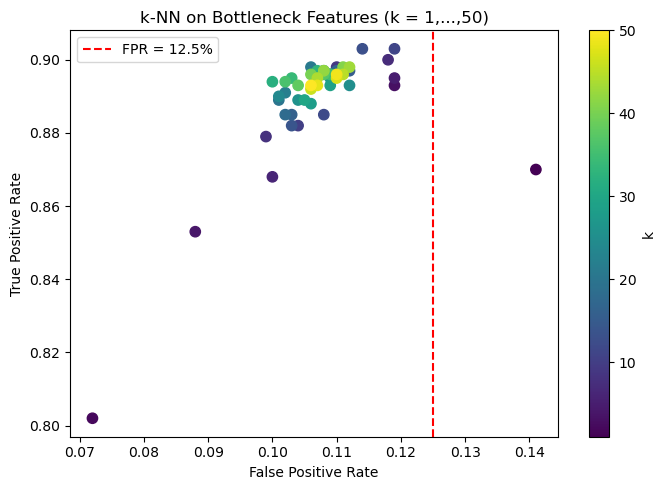

 k   fpr   tpr
 1 0.141 0.870
 2 0.072 0.802
 3 0.119 0.893
 4 0.088 0.853
 5 0.119 0.895
 6 0.100 0.868
 7 0.118 0.900
 8 0.099 0.879
 9 0.110 0.898
10 0.104 0.882


In [24]:
from sklearn.metrics import confusion_matrix

roc_knn_rows = []
for k in range(1, 51):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(bottleneck_train_features, y_train.numpy())
    pred = model.predict(bottleneck_test_features)
    tn, fp, fn, tp = confusion_matrix(y_test.numpy(), pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    roc_knn_rows.append({"k": k, "fpr": fpr, "tpr": tpr})

roc_knn_df = pd.DataFrame(roc_knn_rows)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    roc_knn_df["fpr"],
    roc_knn_df["tpr"],
    c=roc_knn_df["k"],
    cmap="viridis",
    s=55,
)
plt.axvline(0.125, color="red", linestyle="--", label="FPR = 12.5%")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("k-NN on Bottleneck Features (k = 1,...,50)")
plt.legend()
plt.colorbar(scatter, label="k")
plt.tight_layout()
plt.show()

print(roc_knn_df.head(10).to_string(index=False))

Suppose you work for a company that wants to figure out when a shirt appears among photos that have either shirts or pullovers. The company tells you that it cannot tolerate a false positive rate of detecting shirts that is more than 12.5%. What value of number of nearest neighbors $k$ achieves the highest true positive rate, but doesn't have more than a 12.5% false positive rate?

**Write your answer here:**

I would choose **k = 13**. It achieves the highest true positive rate among the classifiers with false positive rate at or below 12.5%, and it slightly improves the false positive rate over the tied alternative `k = 11`.

In [25]:
feasible_knn_df = roc_knn_df[roc_knn_df["fpr"] <= 0.125].sort_values(
    by=["tpr", "fpr", "k"], ascending=[False, True, True]
)
print(feasible_knn_df.head(10).to_string(index=False))

 k   fpr   tpr
13 0.114 0.903
11 0.119 0.903
 7 0.118 0.900
21 0.106 0.898
 9 0.110 0.898
41 0.111 0.898
43 0.112 0.898
33 0.107 0.897
19 0.108 0.897
39 0.108 0.897


# Part 3: Sentiment Analysis [30 points]

Download data from: http://www.andrew.cmu.edu/user/georgech/HW3-data.zip <br>

The folder contains:

- `train.csv`
- `test.csv`

In this problem, we look at predicting whether a tweet has positive or negative sentiment.

**We intentionally wrote this problem to be a bit open-ended to let you play with different neural net code yourself.** We will give full credit even if you subsample the training data. However, do not subsample the test dataset (which is small anyways). If you want to have practice with what it's like working with a sizable dataset though, we do encourage you to try to use as much of the training data as possible (our solution code uses the full training data in an 80-20 split between a proper training set and a validation set, just like in lectures).

Note that using all the data does involve more careful data preprocessing to avoid possible memory issues. Some suggestions: using your knowledge from weeks 1 and 2, you can write your own code to tokenize tweets and only include some of the tokens (e.g., only keeping the most common 1000 tokens, etc); in particular you can build your own vocabulary. As a suggestion, you could make vocabulary token \#0 correspond to a special padding character `"<pad>"`; this special index 0 will in fact be automatically added by the batching process for recurrent neural nets when making different tweets within the same batch have the same length. As another suggestion, you could make a special vocabulary token `"<unk>"` for unknown tokens that you've decided not to keep track of. For example, if you only keep track of the most common 1000 tokens, then any token that is not one of these most common 1000 gets represented as `"<unk>"`.

**(a) [5 points]** We first read in the tweet data. Read the data present in `train.csv` file. **Please do not change the filename. In particular, use a relative path, i.e., `./HW3-data/train.csv`**. Then do the following:

1. Keep only the sentiment and sentiment text in the data - the first and the last coumn
2. Print the number of positive and negative sentiment labels

Note: If you are using `open()`, you may have to set `encoding='iso8859'`.

In [26]:
import pandas as pd

tweet_train_df = pd.read_csv(
    "./HW3-data/train.csv",
    header=None,
    usecols=[0, 5],
    names=["sentiment", "text"],
    encoding="iso8859-1",
)

label_counts = tweet_train_df["sentiment"].value_counts().sort_index()
print("Negative tweets:", label_counts[0])
print("Positive tweets:", label_counts[1])

tweet_train_df.head()

Negative tweets: 800000
Positive tweets: 800000


,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


**(b) [25 points]** Modify the LSTM demo code from lecture to work with this Twitter dataset. Play with the learning rate and batch size so that the training gives reasonable increases in validation accuracy scores as we progress through epochs (leave the number of epochs at 10). Also feel free to try different neural net architectures (although you do not have to). What test accuracy are you able to achieve?

Epoch 01: train_loss=0.5707, train_acc=0.6855, val_loss=0.4851, val_acc=0.7666
Epoch 02: train_loss=0.4637, train_acc=0.7801, val_loss=0.4530, val_acc=0.7864
Epoch 03: train_loss=0.4423, train_acc=0.7931, val_loss=0.4401, val_acc=0.7939
Epoch 04: train_loss=0.4322, train_acc=0.7992, val_loss=0.4326, val_acc=0.7976
Epoch 05: train_loss=0.4251, train_acc=0.8031, val_loss=0.4277, val_acc=0.8010
Epoch 06: train_loss=0.4203, train_acc=0.8060, val_loss=0.4249, val_acc=0.8025
Epoch 07: train_loss=0.4160, train_acc=0.8081, val_loss=0.4210, val_acc=0.8042
Epoch 08: train_loss=0.4125, train_acc=0.8101, val_loss=0.4186, val_acc=0.8055
Epoch 09: train_loss=0.4095, train_acc=0.8115, val_loss=0.4177, val_acc=0.8058
Epoch 10: train_loss=0.4066, train_acc=0.8133, val_loss=0.4152, val_acc=0.8074
Best validation accuracy: 0.8074
Test accuracy: 0.6185


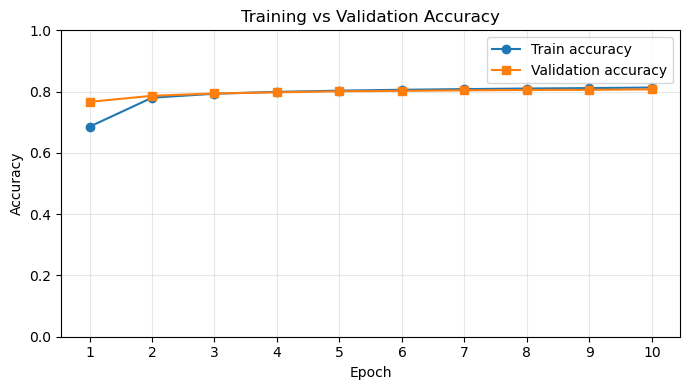

In [27]:
import gc
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(0)
torch.manual_seed(0)

X_train_text, X_val_text, y_train_text, y_val_text = train_test_split(
    tweet_train_df["text"],
    tweet_train_df["sentiment"],
    test_size=0.2,
    random_state=0,
    stratify=tweet_train_df["sentiment"],
)
del tweet_train_df

tweet_test_df = pd.read_csv(
    "./HW3-data/test.csv",
    header=None,
    usecols=[0, 5],
    names=["sentiment", "text"],
    encoding="utf-8",
)

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"@\w+", " <user> ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^a-z0-9!?\'\s<>]+", " ", text)
    text = re.sub(r"\d+", " <num> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

token_pattern = re.compile(r"<url>|<user>|<num>|[a-z]+(?:'[a-z]+)?|[!?]")

def tokenize_tweet(text):
    return token_pattern.findall(clean_tweet(text))

vocab_counter = Counter()
for text in X_train_text:
    vocab_counter.update(tokenize_tweet(text))

# We use the full training set and keep the model lightweight enough
# that 10 epochs remain practical to run.
max_vocab = 10000
max_len = 20
idx_to_token = ["<pad>", "<unk>"] + [
    token for token, _ in vocab_counter.most_common(max_vocab - 2)
]
token_to_idx = {token: idx for idx, token in enumerate(idx_to_token)}

def encode_text_list(text_list):
    encoded = np.zeros((len(text_list), max_len), dtype=np.int64)
    for i, text in enumerate(text_list):
        token_ids = [token_to_idx.get(token, 1) for token in tokenize_tweet(text)[:max_len]]
        encoded[i, : len(token_ids)] = token_ids
    return encoded

X_train_encoded = encode_text_list(X_train_text)
X_val_encoded = encode_text_list(X_val_text)
X_test_encoded = encode_text_list(tweet_test_df["text"])

y_train_tensor = torch.tensor(y_train_text.to_numpy(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val_text.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(tweet_test_df["sentiment"].tolist(), dtype=torch.long)

del X_train_text, X_val_text, y_train_text, y_val_text
gc.collect()

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_encoded), y_train_tensor),
    batch_size=4096,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_encoded), y_val_tensor),
    batch_size=4096,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_encoded), y_test_tensor),
    batch_size=4096,
    shuffle=False,
)

class TweetLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return self.classifier(self.dropout(hidden[-1]))

tweet_lstm = TweetLSTM(len(idx_to_token))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tweet_lstm.parameters(), lr=1e-3)

history = UDA_pytorch_classifier_fit(
    tweet_lstm,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device="cpu",
    clip_grad_norm=1.0,
)

UDA_plot_train_val_accuracy_vs_epoch(history["train_acc"], history["val_acc"])

tweet_test_pred = []
tweet_test_true = []
tweet_lstm.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = tweet_lstm(xb)
        tweet_test_pred.append(logits.argmax(dim=1))
        tweet_test_true.append(yb)

tweet_test_pred = torch.cat(tweet_test_pred)
tweet_test_true = torch.cat(tweet_test_true)
part3_test_accuracy = UDA_compute_accuracy(tweet_test_true, tweet_test_pred)

print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Test accuracy: {part3_test_accuracy:.4f}")